In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Parameters
e0 = 8.854187817e-12  # Vacuum permittivity (F/m)
mu0 = 4 * np.pi * 1e-7  # Vacuum permeability (H/m)
vp = 1 / np.sqrt(e0 * mu0)

a = 1 # tamanho da reta (eixo x)
T = 10e-9 # tempo de simulação 

dx = 0.01
dt = 0.005e-9

nx = int(a / dx) + 1
nt = int(T / dt)

xgrid = np.linspace(0, a, nx)

# campos
Ey = np.zeros((nt, nx))
Hz = np.zeros((nt, nx))

# valor inicial do campo Ey em t = 0
Ey[0, :] = np.sin(np.pi / a * xgrid)

# marcha no tempo
for n in range(nt - 1):

    # atualiza o H
    for i in range(nx - 1):
        Hz[n+1, i] = Hz[n, i] + (dt / (mu0 * dx)) * (Ey[n, i+1] - Ey[n, i])

    # atualiza o E
    for i in range(1, nx - 1):
        # por causa do i-1 no final que o range começa em 1
        Ey[n+1, i] = Ey[n, i] + (dt / (e0 * dx)) * (Hz[n+1, i] - Hz[n+1, i-1])

    # zero na condição de contorno (extremidades)
    Ey[n+1, 0] = 0
    Ey[n+1, -1] = 0



In [73]:
conv = vp * dt / dx
print(f"Condição de estabilidade (CFL): {conv:.2f}")

Condição de estabilidade (CFL): 0.15


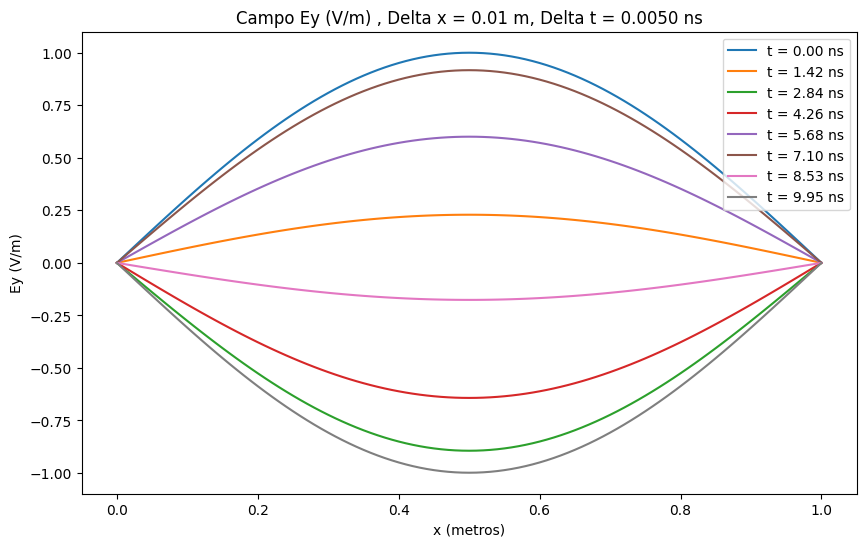

In [74]:
# Plot a few time snapshots
t_list = np.linspace(0, nt - 10, 8, dtype=int)
plt.figure(figsize=(10, 6))
for k in range(len(t_list)):
    plt.plot(xgrid, Ey[t_list[k], :], label=f"t = {t_list[k]*dt*1e9:.2f} ns")
plt.title(f"Campo Ey (V/m) , Delta x = {dx} m, Delta t = {dt*1e9:.4f} ns")
plt.xlabel("x (metros)")
plt.ylabel(f"Ey (V/m)")
plt.legend(loc='upper right')
plt.show()

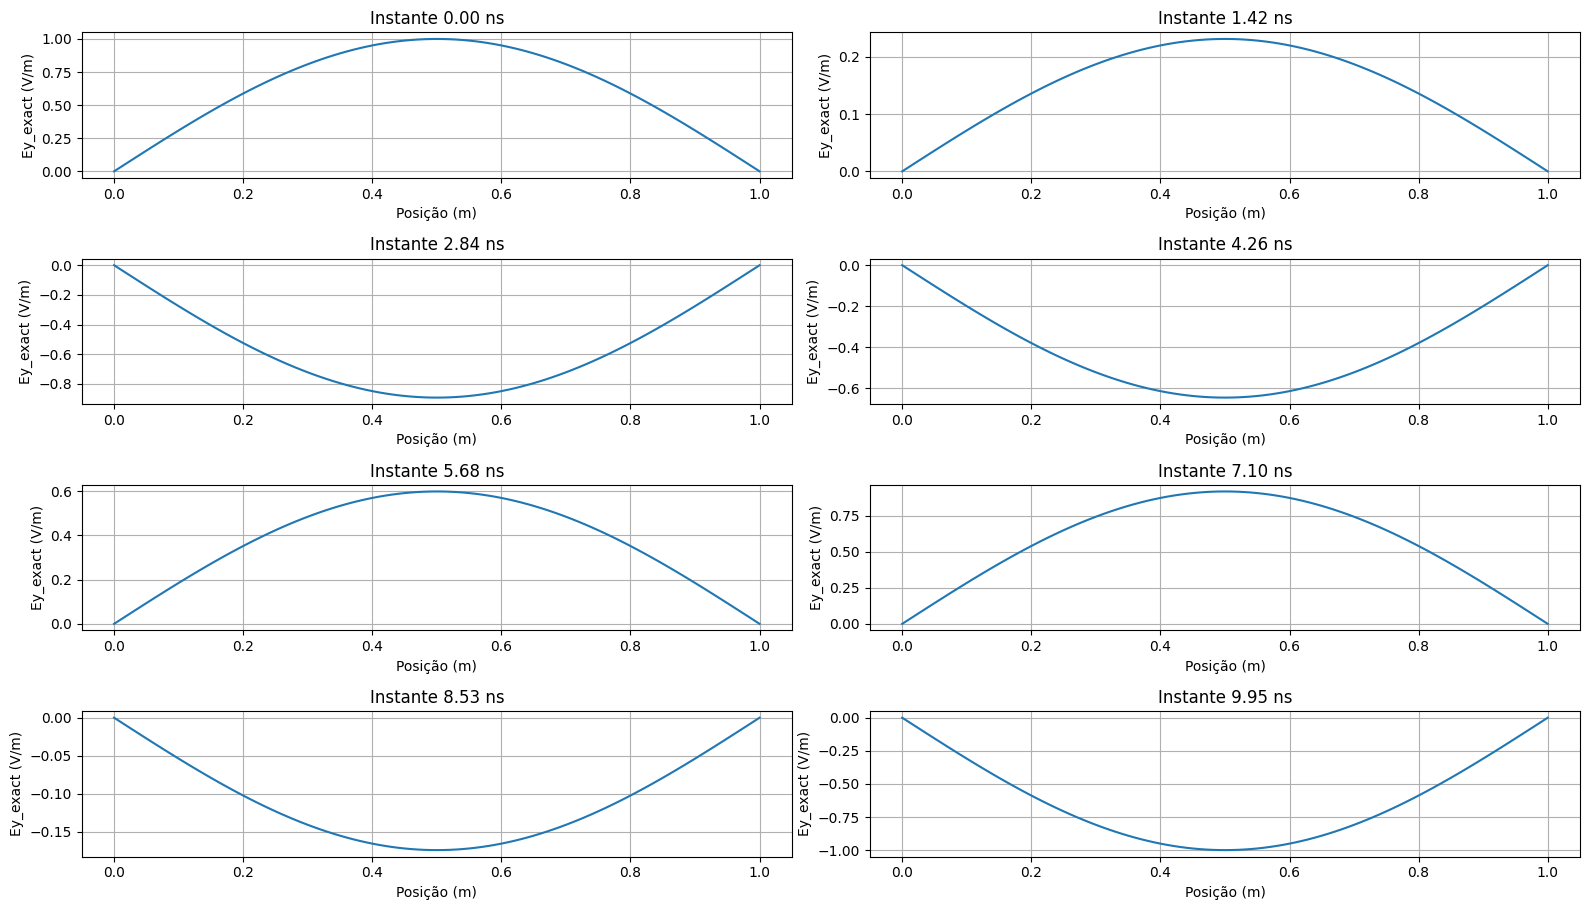

In [75]:
# preenche com a solução exata
# campos
Ey_exact = np.zeros((nt, nx))
Hz_exact = np.zeros((nt, nx))

for n in range(nt):
    for i in range(nx):
        curr_t = n * dt
        curr_x = i * dx

        Ey_exact[n, i] = np.cos(vp * np.pi / a * curr_t) * np.sin(np.pi / a * curr_x)
        Hz_exact[n, i] = -1 * np.sin(vp * np.pi / a * curr_t) * np.cos(np.pi / a * curr_x)

fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(16, 10))

# Plot a few time snapshots
t_list = np.linspace(0, nt - 10, 8, dtype=int)

for k, ax in enumerate(axes.flatten()):
    ax.plot(xgrid, Ey_exact[t_list[k], :], label=f"t = {t_list[k]*dt*1e9:.2f} ns")
    ax.set_title(f'Instante {t_list[k] *  dt* 1e9:.2f} ns')      # Set a title for each subplot
    ax.set_xlabel('Posição (m)')
    ax.set_ylabel('Ey_exact (V/m)')
    ax.grid(True)

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust rect to make space for suptitle

plt.show()

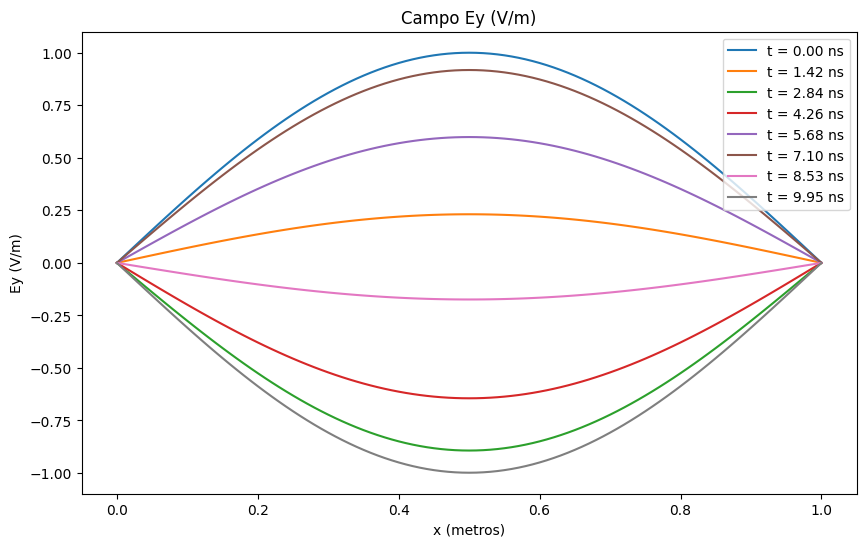

In [76]:
# Plot a few time snapshots
t_list = np.linspace(0, nt - 10, 8, dtype=int)
plt.figure(figsize=(10, 6))
for k in range(len(t_list)):
    plt.plot(xgrid, Ey_exact[t_list[k], :], label=f"t = {t_list[k]*dt*1e9:.2f} ns")
plt.title("Campo Ey (V/m)")
plt.xlabel("x (metros)")
plt.ylabel("Ey (V/m)")
plt.legend(loc='upper right')
plt.show()